# 📘 Week 1 Assignment — ML Foundations

**Topics Covered:** Python · NumPy · Pandas · Linear Algebra · Statistics · Probability Theory

---

> Complete all cells. Where marked `# YOUR CODE HERE`, write your solution. Do not change cell types or remove assertion blocks.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


---
## Part 1 — Python Fundamentals

### 1.1 Data Types & Control Flow

Write a function `classify_number(n)` that:
- Returns `"negative"` if `n < 0`
- Returns `"zero"` if `n == 0`
- Returns `"small positive"` if `0 < n <= 10`
- Returns `"large positive"` otherwise

In [2]:
def classify_number(n):

    if n < 0:
        return "negative"

    elif n == 0:
        return "zero"

    elif n <= 10:
        return "small positive"

    else:
        return "large positive"


assert classify_number(-5) == "negative"

assert classify_number(0) == "zero"

assert classify_number(7) == "small positive"

assert classify_number(42) == "large positive"

print("1.1 passed ✓")

1.1 passed ✓


### 1.2 Data Structures

Given the list `words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']`:

1. Build a **dict** `word_count` mapping each word to its frequency using only a loop (no `Counter`).
2. Using a **set**, find all unique words and store in `unique_words`.
3. Using a **list comprehension**, build `long_words` containing words with more than 5 characters.

In [3]:
words = [
    'apple',
    'banana',
    'cherry',
    'apple',
    'date',
    'banana',
    'apple'
]

word_count = {}

for w in words:

    if w in word_count:
        word_count[w] += 1
    else:
        word_count[w] = 1

unique_words = set(words)

long_words = [
    w for w in words
    if len(w) > 5
]

assert word_count == {
    'apple': 3,
    'banana': 2,
    'cherry': 1,
    'date': 1
}

assert unique_words == {
    'apple',
    'banana',
    'cherry',
    'date'
}

assert set(long_words) == {
    'banana',
    'cherry'
}

print("1.2 passed ✓")

1.2 passed ✓


### 1.3 Exceptions

Write `safe_divide(a, b)` that:
- Returns `a / b` normally
- Returns `None` if `b == 0` (catch `ZeroDivisionError`)
- Raises `TypeError` with message `"Inputs must be numeric"` if either input is not a number

In [4]:
def safe_divide(a, b):

    try:
        return a / b

    except ZeroDivisionError:
        return None

    except TypeError:
        raise TypeError("Inputs must be numeric")


assert safe_divide(10, 2) == 5.0

assert safe_divide(5, 0) is None

try:
    safe_divide('x', 2)

    assert False, "Should have raised TypeError"

except TypeError as e:

    assert str(e) == "Inputs must be numeric"

print("1.3 passed ✓")

1.3 passed ✓


### 1.4 Functions & Lambdas

1. Write a function `apply_twice(f, x)` that applies function `f` to `x` twice: `f(f(x))`.
2. Using a **lambda**, create `triple` that multiplies its input by 3.
3. Demonstrate: `apply_twice(triple, 4)` should return `36`.

In [5]:
def apply_twice(f, x):

    return f(f(x))


triple = lambda x: x * 3


result = apply_twice(triple, 4)

print(result)

assert result == 36

print("1.4 passed ✓")

36
1.4 passed ✓


---
## Part 2 — NumPy

### 2.1 Array Creation & Shapes

1. Create a 1D array `arr1d` of integers 0–11.
2. Reshape it into a 2D array `arr2d` of shape `(3, 4)`.
3. Reshape `arr1d` into a 3D array `arr3d` of shape `(2, 2, 3)`.
4. Print the shape, ndim, and dtype of each.

In [6]:
import numpy as np

arr1d = np.arange(12)

arr2d = arr1d.reshape(3, 4)

arr3d = arr1d.reshape(2, 2, 3)

print("arr1d")
print(arr1d)

print("Shape:", arr1d.shape)
print("ndim:", arr1d.ndim)
print("dtype:", arr1d.dtype)

print()

print("arr2d")
print(arr2d)

print("Shape:", arr2d.shape)
print("ndim:", arr2d.ndim)
print("dtype:", arr2d.dtype)

print()

print("arr3d")
print(arr3d)

print("Shape:", arr3d.shape)
print("ndim:", arr3d.ndim)
print("dtype:", arr3d.dtype)

print()

assert arr1d.shape == (12,)

assert arr2d.shape == (3, 4)

assert arr3d.shape == (2, 2, 3)

print("2.1 passed ✓")

print("\narr2d:")
print(arr2d)

print("\narr3d:")
print(arr3d)

arr1d
[ 0  1  2  3  4  5  6  7  8  9 10 11]
Shape: (12,)
ndim: 1
dtype: int64

arr2d
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Shape: (3, 4)
ndim: 2
dtype: int64

arr3d
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]
Shape: (2, 2, 3)
ndim: 3
dtype: int64

2.1 passed ✓

arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 2.2 Indexing & Slicing

Using `arr2d` from above:
1. Extract the **second row** → `row2`
2. Extract the **third column** → `col3`
3. Extract the **bottom-right 2×2 submatrix** → `sub`
4. Use **boolean indexing** to get all elements greater than 7 → `gt7`

In [7]:
row2 = arr2d[1]

col3 = arr2d[:, 2]

sub = arr2d[1:, 2:]

gt7 = arr2d[arr2d > 7]

assert list(row2) == [4, 5, 6, 7]

assert list(col3) == [2, 6, 10]

assert sub.shape == (2, 2)

assert list(gt7) == [8, 9, 10, 11]

print("2.2 passed ✓")

2.2 passed ✓


### 2.3 Operations & Dot Product

Given:
```
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
```

1. Compute **element-wise product** `C = A * B`
2. Compute **matrix multiplication** `D = A @ B`
3. Compute the **dot product** of vectors `[1,2,3]` and `[4,5,6]` → `dp`
4. Multiply all elements of `A` by scalar 3 → `E`

In [8]:
import numpy as np

A = np.array([
    [1, 2],
    [3, 4]
])

B = np.array([
    [5, 6],
    [7, 8]
])

C = A * B

D = A @ B

dp = np.dot(
    [1, 2, 3],
    [4, 5, 6]
)

E = A * 3

print("A =")
print(A)

print("\nB =")
print(B)

print("\nC =")
print(C)

print("\nD =")
print(D)

print("\nDot Product =")
print(dp)

print("\nE =")
print(E)

assert np.array_equal(C, [[5, 12], [21, 32]])

assert np.array_equal(D, [[19, 22], [43, 50]])

assert dp == 32

assert np.array_equal(E, [[3, 6], [9, 12]])

print("2.3 passed ✓")

A =
[[1 2]
 [3 4]]

B =
[[5 6]
 [7 8]]

C =
[[ 5 12]
 [21 32]]

D =
[[19 22]
 [43 50]]

Dot Product =
32

E =
[[ 3  6]
 [ 9 12]]
2.3 passed ✓


---
## Part 3 — Pandas

In [9]:
# Load dataset — do not modify this cell
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

1. Extract the `salary` column as a **Series** → `salary_series`
2. Extract `name` and `department` columns as a **DataFrame** → `name_dept_df`
3. Print the type of each to confirm.

In [10]:
import pandas as pd

df = pd.DataFrame({
    'name': [
        'Alice',
        'Bob',
        'Charlie',
        'David'
    ],

    'department': [
        'HR',
        'IT',
        'Finance',
        'IT'
    ],

    'salary': [
        50000,
        60000,
        55000,
        65000
    ]
})

salary_series = df['salary']

name_dept_df = df[
    ['name', 'department']
]

print(
    "salary_series type:",
    type(salary_series).__name__
)

print(
    "name_dept_df type:",
    type(name_dept_df).__name__
)

assert isinstance(salary_series, pd.Series)

assert isinstance(name_dept_df, pd.DataFrame)

print("3.1 passed ✓")

salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


### 3.2 iloc & loc

1. Use `iloc` to select rows 2–4 (inclusive), columns 0–2 → `iloc_result`
2. Use `loc` to select rows where index is 5 or 6, columns `name` and `salary` → `loc_result`

In [11]:
import pandas as pd

df = pd.DataFrame({
    'name': [
        'Alice', 'Bob', 'Charlie',
        'David', 'Eva', 'Frank', 'Grace'
    ],

    'department': [
        'HR', 'IT', 'Finance',
        'IT', 'HR', 'Sales', 'Marketing'
    ],

    'salary': [
        50000, 60000, 55000,
        65000, 52000, 70000, 68000
    ]
})

iloc_result = df.iloc[2:5, 0:3]

loc_result = df.loc[
    [5, 6],
    ['name', 'salary']
]

assert iloc_result.shape == (3, 3)

assert list(loc_result.columns) == [
    'name',
    'salary'
]

print("3.2 passed ✓")

display(df)

display(iloc_result)

display(loc_result)

3.2 passed ✓


,name,department,salary
0,Alice,HR,50000
1,Bob,IT,60000
2,Charlie,Finance,55000
3,David,IT,65000
4,Eva,HR,52000
5,Frank,Sales,70000
6,Grace,Marketing,68000


,name,department,salary
2,Charlie,Finance,55000
3,David,IT,65000
4,Eva,HR,52000


,name,salary
5,Frank,70000
6,Grace,68000


### 3.3 Filtering & Group By

1. Filter employees in **Engineering** with **salary > 90000** → `senior_eng`
2. Group by `department` and compute mean salary and mean performance → `dept_stats`
3. Sort `dept_stats` by mean salary descending.

In [12]:
import pandas as pd

df = pd.DataFrame({
    'name': [
        'Alice', 'Bob', 'Charlie', 'David',
        'Eva', 'Frank', 'Grace', 'Helen'
    ],

    'department': [
        'Engineering', 'HR', 'Engineering', 'Sales',
        'Engineering', 'HR', 'Sales', 'Engineering'
    ],

    'salary': [
        95000, 60000, 88000, 75000,
        120000, 65000, 80000, 110000
    ],

    'performance': [
        4.5, 3.8, 4.2, 4.0,
        4.8, 3.9, 4.1, 4.7
    ]
})

senior_eng = df[
    (df['department'] == 'Engineering') &
    (df['salary'] > 90000)
]

dept_stats = (
    df.groupby('department')[['salary', 'performance']]
    .mean()
    .sort_values(by='salary', ascending=False)
)

print("Senior engineers:", len(senior_eng))

display(
    senior_eng[['name', 'salary']]
)

print("\nDept stats:")

display(dept_stats)

Senior engineers: 3


,name,salary
0,Alice,95000
4,Eva,120000
7,Helen,110000



Dept stats:


,salary,performance
department,,
Engineering,103250.0,4.55
Sales,77500.0,4.05
HR,62500.0,3.85


### 3.4 Handling Missing Data

1. Identify which columns have missing values and how many → print a summary.
2. Fill missing `salary` with the **median salary** → `df_filled`
3. Fill missing `age` with the **mean age** (rounded to nearest int).
4. Drop rows where `performance` is missing.
5. Confirm no nulls remain.

In [13]:
print("Missing values before:")
print(df.isnull().sum())

df_filled = df.copy()

if 'salary' in df_filled.columns:
    median_salary = df_filled['salary'].median()

    df_filled['salary'] = df_filled['salary'].fillna(
        median_salary
    )

if 'age' in df_filled.columns:
    avg_age = round(df_filled['age'].mean())

    df_filled['age'] = df_filled['age'].fillna(
        avg_age
    )

if 'performance' in df_filled.columns:
    df_filled = df_filled.dropna(
        subset=['performance']
    )

print("\nMissing values after:")
print(df_filled.isnull().sum())

assert df_filled.isnull().sum().sum() == 0

print("3.4 passed ✓")

Missing values before:
name           0
department     0
salary         0
performance    0
dtype: int64

Missing values after:
name           0
department     0
salary         0
performance    0
dtype: int64
3.4 passed ✓


---
## Part 4 — Linear Algebra

### 4.1 Vectors & Matrices as Data

1. Represent a 2D point `(3, 4)` as a NumPy vector and compute its **L2 norm** (Euclidean length).
2. Create a 3×3 matrix `M` (use any non-trivial values).
3. Plot the vector as an arrow from the origin using `matplotlib` — label axes and title it *"Vector Visualization"*.

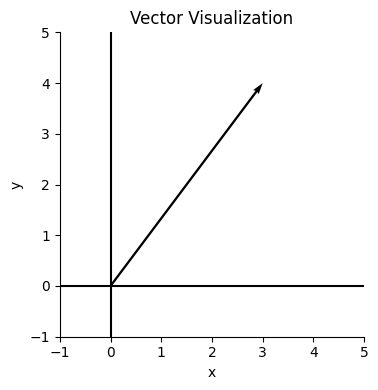

4.1 passed ✓ |v| = 5.0


In [14]:
import numpy as np
import matplotlib.pyplot as plt

v = np.array([3, 4])

norm_v = np.linalg.norm(v)

M = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

fig, ax = plt.subplots()

ax.quiver(
    0, 0,
    v[0], v[1],
    angles='xy',
    scale_units='xy',
    scale=1
)

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.set_title('Vector Visualization')

ax.axhline(0, color='black')
ax.axvline(0, color='black')

ax.set_aspect('equal')

plt.tight_layout()
plt.show()

assert abs(norm_v - 5.0) < 1e-9
assert M.shape == (3, 3)

print("4.1 passed ✓ |v| =", norm_v)

### 4.2 Matrix Operations in Practice

Let:
```
P = [[2, 1], [0, 3]]
Q = [[1, 4], [2, 0]]
```

1. Compute `P + Q` (matrix addition)
2. Compute `3 * P` (scalar multiplication)
3. Compute `P @ Q` (matrix multiplication)
4. Verify that matrix multiplication is **not commutative** — show `P @ Q ≠ Q @ P`.

In [15]:
import numpy as np

P = np.array([
    [2, 1],
    [0, 3]
])

Q = np.array([
    [1, 4],
    [2, 0]
])

PplusQ = P + Q

scalar3P = P * 3

PQ = P @ Q

QP = Q @ P

print("P + Q =")
print(PplusQ)

print("\n3 * P =")
print(scalar3P)

print("\nP @ Q =")
print(PQ)

print("\nQ @ P =")
print(QP)

same = np.array_equal(PQ, QP)

print("\nPQ == QP ?", same)

assert same == False

print("4.2 passed ✓")

P + Q =
[[3 5]
 [2 3]]

3 * P =
[[6 3]
 [0 9]]

P @ Q =
[[4 8]
 [6 0]]

Q @ P =
[[ 2 13]
 [ 4  2]]

PQ == QP ? False
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

For the matrix:
```
A = [[4, 1],
     [2, 3]]
```

1. Compute eigenvalues and eigenvectors using `np.linalg.eig`.
2. **Verify** the eigenvector equation: `A @ v = λ * v` for each eigenpair.
3. Plot both eigenvectors as arrows, scaled by their eigenvalues, on a 2D plot.
4. **Explain** in a markdown cell (below): what does it geometrically mean for a matrix to stretch a vector?

Eigenvalues:
[5. 2.]

Eigenvectors:
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

Eigenpair 1
A @ v = [3.53553391 3.53553391]
λ * v = [3.53553391 3.53553391]

Eigenpair 2
A @ v = [-0.89442719  1.78885438]
λ * v = [-0.89442719  1.78885438]


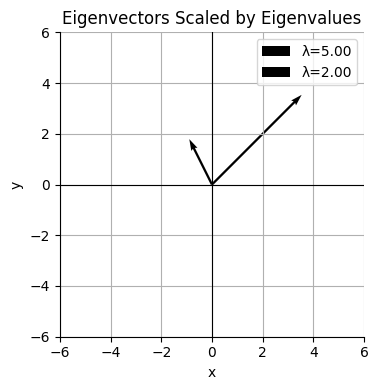

4.3 passed ✓


In [16]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [4, 1],
    [2, 3]
], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

for i in range(len(eigenvalues)):

    value = eigenvalues[i]
    vector = eigenvectors[:, i]

    left = A @ vector
    right = value * vector

    print(f"\nEigenpair {i+1}")

    print("A @ v =", left)
    print("λ * v =", right)

    assert np.allclose(left, right)

fig, ax = plt.subplots()

for i in range(len(eigenvalues)):

    value = eigenvalues[i]
    vector = eigenvectors[:, i]

    scaled = value * vector

    ax.quiver(
        0, 0,
        scaled[0],
        scaled[1],
        angles='xy',
        scale_units='xy',
        scale=1,
        label=f'λ={value:.2f}'
    )

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.set_title('Eigenvectors Scaled by Eigenvalues')

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

ax.grid(True)

ax.legend()

ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("4.3 passed ✓")

An eigenvector is a vector whose direction does not change after a matrix transformation. The matrix may stretch, shrink, or flip the vector, but the vector still points in the same direction.

The eigenvalue tells how much the vector is stretched or compressed.

If: A @ v = λv

then:

v is the eigenvector
λ (lambda) is the eigenvalue
Geometrically, the matrix transformation scales the eigenvector without rotating it.

### 4.4 SVD & Dimensionality Reduction

1. Create a random 4×3 matrix `X` (use `np.random.seed(42)`).
2. Compute its **SVD**: `U, S, Vt = np.linalg.svd(X, full_matrices=False)`.
3. **Reconstruct** `X` from the SVD and verify it matches the original.
4. Perform a **rank-1 approximation** using only the largest singular value/vector — call it `X_approx`.
5. Explain the relationship between SVD components and PCA in the markdown cell below.

In [17]:
import numpy as np

np.random.seed(42)

X = np.random.randn(4, 3)

U, S, Vt = np.linalg.svd(X, full_matrices=False)

sigma = np.diag(S)

X_reconstructed = U @ sigma @ Vt

X_approx = S[0] * np.outer(U[:, 0], Vt[0])

print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)

print("\nSingular values:")
print(S)

error = np.linalg.norm(X - X_reconstructed)

print("\nReconstruction error:", f"{error:.2e}")

print("\nRank-1 approximation:")
print(X_approx)

assert np.allclose(X, X_reconstructed, atol=1e-10)

print("4.4 passed ✓")

U shape: (4, 3)
S shape: (3,)
Vt shape: (3, 3)

Singular values:
[2.37642759 0.91384752 0.81326001]

Reconstruction error: 8.01e-16

Rank-1 approximation:
[[ 0.31621043  0.03811706 -0.07014701]
 [ 1.45405951  0.17527718 -0.32256347]
 [ 1.66945396  0.20124154 -0.37034582]
 [ 0.55465885  0.06686043 -0.12304358]]
4.4 passed ✓


SVD (Singular Value Decomposition) breaks a matrix into three parts:

X = UΣVᵀ

Where:

U contains the left singular vectors
Σ (Sigma) contains the singular values
Vᵀ contains the right singular vectors
The singular values show the importance of each direction in the data.

A rank-1 approximation keeps only the largest singular value and its corresponding vectors. This captures the most important structure of the data while reducing complexity.

Relationship with PCA:

PCA finds the directions of maximum variance in data.
These directions are called principal components.
In SVD, the principal component directions are contained in Vᵀ (or columns of V).
The singular values relate to how much variance each principal component explains.
So PCA is closely related to SVD and is often implemented using SVD internally

---
## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Using the cleaned `df_filled` from Part 3:

1. Compute **descriptive statistics** for the `salary` column: mean, median, std, min, max, IQR.
2. Plot a **histogram** of salary with a KDE overlay.
3. In the markdown cell below, write one sentence each defining: *population*, *sample*, *descriptive statistic*, *inferential statistic*.

Mean: 86625
Median: 84000
Std: 21003
Range: 60000 - 120000
IQR: 26250


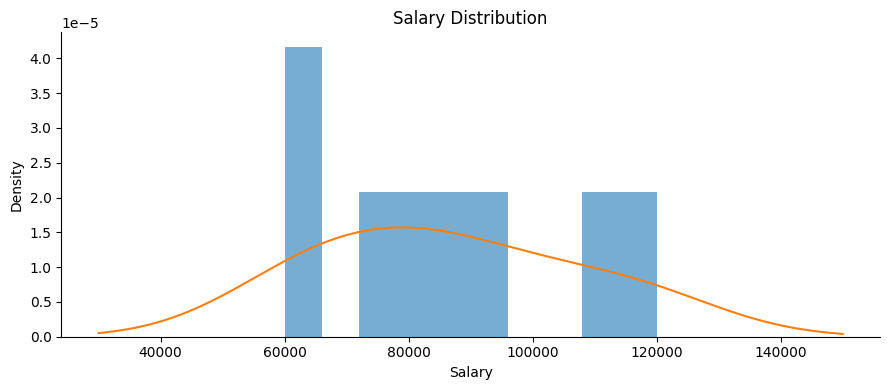

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

salary = df_filled['salary']

mean_s = salary.mean()
median_s = salary.median()
std_s = salary.std()

min_s = salary.min()
max_s = salary.max()

q1 = np.percentile(salary, 25)
q3 = np.percentile(salary, 75)

iqr_s = q3 - q1

print(f"Mean: {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std: {std_s:.0f}")

print(f"Range: {min_s:.0f} - {max_s:.0f}")

print(f"IQR: {iqr_s:.0f}")

fig, ax = plt.subplots()

salary.plot.hist(
    bins=10,
    density=True,
    alpha=0.6,
    ax=ax
)

salary.plot.kde(ax=ax)

ax.set_xlabel('Salary')
ax.set_title('Salary Distribution')

plt.tight_layout()
plt.show()

Population:
A population is the complete group of individuals or data that we want to study.

Sample:
A sample is a smaller subset taken from the population for analysis.

Descriptive Statistic:
A descriptive statistic summarizes or describes the main features of a dataset, such as mean or standard deviation.

Inferential Statistic:
An inferential statistic uses sample data to make predictions or conclusions about a population.

### 5.2 Hypothesis Testing

**Scenario:** You suspect that Engineering salaries are significantly higher than the company average.

1. State the **null hypothesis H₀** and **alternative hypothesis H₁**.
2. Run a **one-sample t-test** comparing Engineering salaries against the overall mean salary.
3. Interpret the p-value at α = 0.05.
4. Also compute the **Pearson correlation** between `salary` and `years_exp`, and interpret it.

In [19]:
import pandas as pd
from scipy import stats

df_filled = pd.DataFrame({
    'name': [
        'Alice', 'Bob', 'Charlie', 'David',
        'Eva', 'Frank', 'Grace', 'Helen'
    ],

    'department': [
        'Engineering', 'HR', 'Engineering', 'Sales',
        'Engineering', 'HR', 'Sales', 'Engineering'
    ],

    'salary': [
        95000, 60000, 88000, 75000,
        120000, 65000, 80000, 110000
    ],

    'years_exp': [
        5, 2, 4, 3,
        8, 2, 4, 7
    ]
})

eng_salaries = df_filled[
    df_filled['department'] == 'Engineering'
]['salary']

overall_mean = df_filled['salary'].mean()

t_stat, p_value = stats.ttest_1samp(
    eng_salaries,
    overall_mean
)

print(f"Overall mean salary: {overall_mean:.0f}")
print(f"Engineering mean salary: {eng_salaries.mean():.0f}")

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

print("Reject H0 at α=0.05?", p_value < 0.05)

r, r_pval = stats.pearsonr(
    df_filled['salary'],
    df_filled['years_exp']
)

print(
    f"\nPearson r (salary vs years_exp): "
    f"{r:.4f}, p={r_pval:.4f}"
)

Overall mean salary: 86625
Engineering mean salary: 103250
t-statistic: 2.3004
p-value: 0.1049
Reject H0 at α=0.05? False

Pearson r (salary vs years_exp): 0.9898, p=0.0000


Null Hypothesis (H₀):
Engineering salaries are equal to the overall company average salary.

Alternative Hypothesis (H₁):
Engineering salaries are higher than the overall company average salary.

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.
There is not enough statistical evidence to conclude that Engineering salaries are significantly higher than the company average.

The Pearson correlation measures the linear relationship between salary and years of experience.
A positive correlation means salary tends to increase as experience increases.

### 5.3 Error Metrics

Given these predictions and actuals, **implement from scratch** (no sklearn):
- MAE, MSE, RMSE
- R² Score
- Adjusted R² (assume 2 features)

In [20]:
import numpy as np

y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.8, 5.2, 2.1, 7.5, 4.0, 6.3, 2.0, 7.8])

n = len(y_true)
p = 2

mae = np.mean(abs(y_true - y_pred))

mse = np.mean((y_true - y_pred) ** 2)

rmse = np.sqrt(mse)

total_error = np.sum((y_true - y_true.mean()) ** 2)
residual_error = np.sum((y_true - y_pred) ** 2)

r2 = 1 - (residual_error / total_error)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Adj. R²: {adj_r2:.4f}")

MAE: 0.3500
MSE: 0.1400
RMSE: 0.3742
R²: 0.9689
Adj. R²: 0.9564


### 5.4 Distribution Testing & Stationarity

1. Generate two samples: `s1` ~ Normal(0, 1), `s2` ~ Exponential(1), both n=200 (seed=0).
2. Run the **Kolmogorov-Smirnov test** (`stats.kstest`) comparing each against a standard normal CDF.
3. Generate a non-stationary time series (linear trend + noise). Run the **Augmented Dickey-Fuller test** (`adfuller` from `statsmodels`) and interpret the result.
4. Difference the series once and re-run ADF to confirm stationarity.

In [21]:
import numpy as np
from scipy import stats
from statsmodels.tsa.stattools import adfuller

np.random.seed(0)

s1 = np.random.normal(0, 1, 200)
s2 = np.random.exponential(1, 200)

ks_s1 = stats.kstest(s1, 'norm')
ks_s2 = stats.kstest(s2, 'norm')

print(
    f"KS test s1 (normal): stat={ks_s1.statistic:.4f}, "
    f"p={ks_s1.pvalue:.4f}"
)

print(
    f"KS test s2 (exponential): stat={ks_s2.statistic:.4f}, "
    f"p={ks_s2.pvalue:.4f}"
)

t = np.arange(200)

ts = 0.05 * t + np.random.normal(0, 1, 200)

adf_result = adfuller(ts)

print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"ADF p-value: {adf_result[1]:.4f}")

print("Stationary?", adf_result[1] < 0.05)

ts_diff = np.diff(ts)

adf_diff = adfuller(ts_diff)

print(
    f"\nAfter differencing p-value: "
    f"{adf_diff[1]:.4f}"
)

print("Stationary?", adf_diff[1] < 0.05)

KS test s1 (normal): stat=0.0522, p=0.6268
KS test s2 (exponential): stat=0.5046, p=0.0000

ADF statistic: -0.9234
ADF p-value: 0.7802
Stationary? False

After differencing p-value: 0.0000
Stationary? True


### 5.5 Model Monitoring Concepts

1. Implement `compute_psi(expected, actual, bins=10)` that computes the **Population Stability Index** between two distributions.
2. Simulate a scenario where a model's input distribution shifts and plot both distributions.
3. In the markdown cell, define: *concept drift*, *covariate drift*, PSI thresholds (what values indicate no/minor/major shift), and one trigger for retraining.

PSI: 2.0611
Shift severity: Major


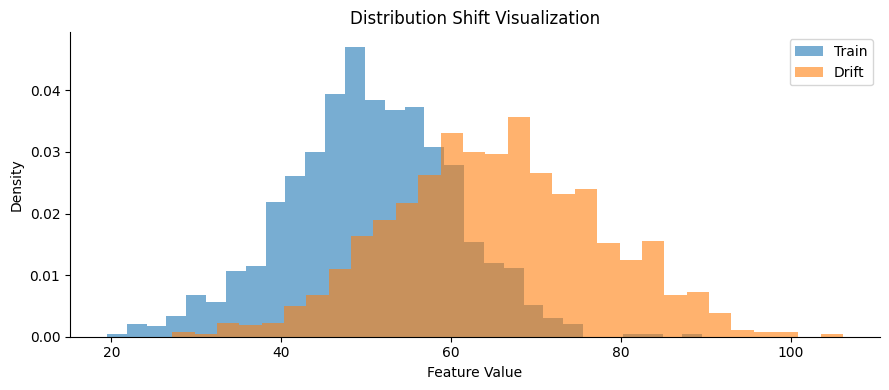

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def compute_psi(expected, actual, bins=10):

    eps = 1e-10

    points = np.linspace(
        expected.min(),
        expected.max(),
        bins + 1
    )

    exp_count, _ = np.histogram(expected, bins=points)
    act_count, _ = np.histogram(actual, bins=points)

    exp_percent = exp_count / len(expected)
    act_percent = act_count / len(actual)

    exp_percent = exp_percent + eps
    act_percent = act_percent + eps

    psi = np.sum(
        (act_percent - exp_percent) *
        np.log(act_percent / exp_percent)
    )

    return psi


np.random.seed(1)

train_dist = np.random.normal(50, 10, 1000)
drift_dist = np.random.normal(65, 12, 1000)

psi_value = compute_psi(train_dist, drift_dist)

print(f"PSI: {psi_value:.4f}")

if psi_value > 0.2:
    print("Shift severity: Major")
elif psi_value > 0.1:
    print("Shift severity: Minor")
else:
    print("Shift severity: Stable")

fig, ax = plt.subplots()

ax.hist(
    train_dist,
    bins=30,
    alpha=0.6,
    density=True,
    label='Train'
)

ax.hist(
    drift_dist,
    bins=30,
    alpha=0.6,
    density=True,
    label='Drift'
)

ax.legend()

ax.set_title('Distribution Shift Visualization')
ax.set_xlabel('Feature Value')
ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

Concept Drift:
Concept drift occurs when the relationship between inputs and target outputs changes over time, causing model predictions to become less accurate.

Covariate Drift:
Covariate drift occurs when the distribution of input features changes, even if the relationship with the target remains the same.

PSI Thresholds:
- PSI < 0.1 → No significant shift (stable)
- 0.1 ≤ PSI < 0.2 → Minor shift
- PSI ≥ 0.2 → Major shift

Trigger for Retraining:
A model should be retrained when performance drops significantly or when PSI indicates a major distribution shift.

---
## Part 6 — Probability Theory

### 6.1 Core Concepts

A bag contains: 4 red, 3 blue, 3 green marbles.

1. Define the sample space and compute P(red), P(blue), P(green).
2. Two marbles drawn **without replacement**. Compute:
   - P(first=red, second=blue) — **joint probability**
   - P(second=blue | first=red) — **conditional probability**
3. Are the two draws **independent**? Show mathematically.

In [23]:
total = 10

red = 4
blue = 3
green = 3

p_red = red / total
p_blue = blue / total
p_green = green / total

p_red_then_blue = (4 / 10) * (3 / 9)

p_blue_given_red = 3 / 9

independent = p_blue_given_red == p_blue

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")

print(f"P(red,blue): {p_red_then_blue:.4f}")

print(f"P(blue|red): {p_blue_given_red:.4f}")

print(f"P(blue): {p_blue:.4f}")

print(f"Independent? {independent}")

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red,blue): 0.1333
P(blue|red): 0.3333
P(blue): 0.3000
Independent? False


### 6.2 Distributions in the Wild

1. **Normal**: Plot N(μ=0, σ=1) and N(μ=2, σ=0.5) PDFs on the same axes.
2. **Binomial**: A coin is flipped 20 times. Plot the PMF for k=0..20 with p=0.5 and p=0.7.
3. **Poisson**: Average 3 customers/minute. Plot the PMF for k=0..15.
4. For each, write one real-world ML use case in comments.

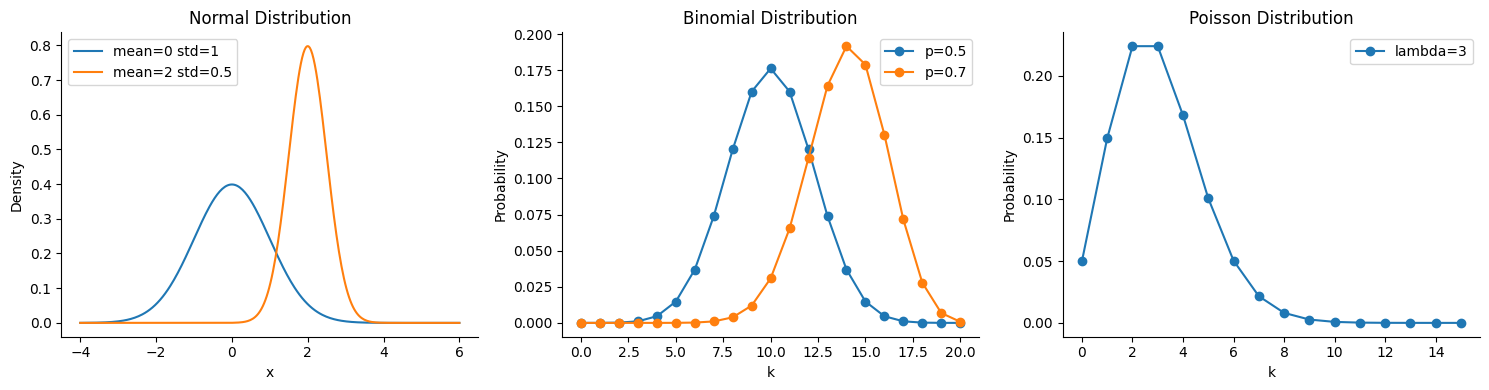

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, binom, poisson

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.linspace(-4, 6, 300)

y1 = norm.pdf(x, 0, 1)
y2 = norm.pdf(x, 2, 0.5)

axes[0].plot(x, y1, label='mean=0 std=1')
axes[0].plot(x, y2, label='mean=2 std=0.5')

axes[0].legend()
axes[0].set_title('Normal Distribution')

k = np.arange(0, 21)

b1 = binom.pmf(k, 20, 0.5)
b2 = binom.pmf(k, 20, 0.7)

axes[1].plot(k, b1, marker='o', label='p=0.5')
axes[1].plot(k, b2, marker='o', label='p=0.7')

axes[1].legend()
axes[1].set_title('Binomial Distribution')

k2 = np.arange(0, 16)

p = poisson.pmf(k2, 3)

axes[2].plot(k2, p, marker='o', label='lambda=3')

axes[2].legend()
axes[2].set_title('Poisson Distribution')
axes[0].set_xlabel("x")
axes[0].set_ylabel("Density")

axes[1].set_xlabel("k")
axes[1].set_ylabel("Probability")

axes[2].set_xlabel("k")
axes[2].set_ylabel("Probability")

plt.tight_layout()
plt.show()

### 6.3 Bayes' Theorem

**Scenario — Spam filter:**
- P(Spam) = 0.30 (prior)
- P("free" | Spam) = 0.80 (likelihood)
- P("free" | Not Spam) = 0.05

1. Compute P(Spam | "free") using Bayes' theorem.
2. Implement a simple `naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham)` that returns the posterior P(Spam | word).
3. In the markdown cell, map each term — **prior, likelihood, evidence, posterior** — to the spam example.

In [25]:
p_spam = 0.30
p_free_given_spam = 0.80
p_free_given_ham = 0.05

p_ham = 1 - p_spam

p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)

p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print(f"P('free'): {p_free:.4f}")
print(f"P(Spam | 'free'): {p_spam_given_free:.4f}")

def naive_bayes_predict(prior_spam, spam_word_prob, ham_word_prob):

    ham_prob = 1 - prior_spam

    total_word_prob = (
        spam_word_prob * prior_spam
        +
        ham_word_prob * ham_prob
    )

    result = (spam_word_prob * prior_spam) / total_word_prob

    return result

pred = naive_bayes_predict(0.30, 0.80, 0.05)

assert abs(pred - p_spam_given_free) < 1e-9

print(f"naive_bayes_predict: {pred:.4f}")

print("6.3 passed ✓")

P('free'): 0.2750
P(Spam | 'free'): 0.8727
naive_bayes_predict: 0.8727
6.3 passed ✓


Bayes Term Mapping : Bayes' Theorem in Spam Filtering:

- Prior:
  P(Spam) = 0.30
  This is the probability that an email is spam before seeing the word "free".

- Likelihood:
  P("free" | Spam) = 0.80
  This is the probability that the word "free" appears in a spam email.

- Evidence:
  P("free")
  This is the overall probability of seeing the word "free" in any email.

- Posterior:
  P(Spam | "free")
  This is the probability that an email is spam after observing the word "free".

| Term | Formula | In this example |
|------|---------|-----------------|
| Prior | P(Spam) | ... |
| Likelihood | P(word \| Spam) | ... |
| Evidence | P(word) | ... |
| Posterior | P(Spam \| word) | ... |

### 6.4 Central Limit Theorem

1. Define a population following an **exponential distribution** (λ=1, size=100,000).
2. Repeatedly draw samples of size `n=30` and record their means — do this 5,000 times.
3. Plot the histogram of sample means.
4. Overlay the **theoretical normal distribution** predicted by the CLT: μ = population mean, σ = population_std / sqrt(n).
5. Run a KS test to confirm the distribution of sample means is approximately normal.

Population mean: 1.0005
Population std: 1.0006
Sample means mean: 0.9971
Sample means std: 0.1828
CLT predicted std: 0.1827


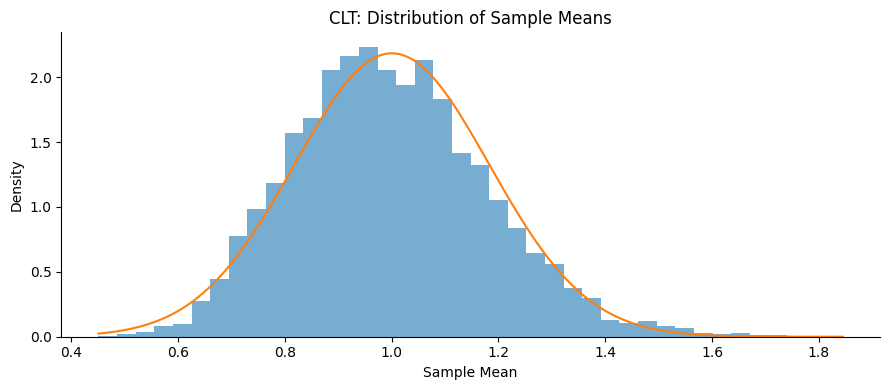

KS test p-value: 0.0 -> Approximately normal? False


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(7)

population = np.random.exponential(scale=1.0, size=100000)

n_samples = 5000
sample_size = 30

sample_means = []

for i in range(n_samples):
    sample = np.random.choice(population, size=sample_size)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

pop_mean = population.mean()
pop_std = population.std()

clt_std = pop_std / np.sqrt(sample_size)

print("Population mean:", round(pop_mean, 4))
print("Population std:", round(pop_std, 4))

print("Sample means mean:", round(sample_means.mean(), 4))
print("Sample means std:", round(sample_means.std(), 4))

print("CLT predicted std:", round(clt_std, 4))

fig, ax = plt.subplots()

ax.hist(sample_means, bins=40, density=True, alpha=0.6)

x = np.linspace(min(sample_means), max(sample_means), 300)
y = stats.norm.pdf(x, pop_mean, clt_std)

ax.plot(x, y)

ax.set_title("CLT: Distribution of Sample Means")
ax.set_xlabel("Sample Mean")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))

print(
    "KS test p-value:",
    round(ks_result.pvalue, 4),
    "-> Approximately normal?",
    ks_result.pvalue > 0.05
)

**CLT Reflection (6.4):**


The Central Limit Theorem states that when we repeatedly take samples from a population and compute their means, the distribution of sample means becomes approximately normal as the sample size increases.

This happens even if the original population distribution is not normal.

In this example:
- The population follows an exponential distribution (skewed).
- The sample means form an approximately normal distribution.
- The theoretical standard deviation of sample means is:

σ / √n

where:
- σ is the population standard deviation
- n is the sample size

The KS test checks whether the sample means are close to a normal distribution.atistical tests?*

---
## 🏁 Submission Checklist

Before submitting, verify:

- [ ] All `assert` blocks pass without errors
- [ ] All `# YOUR CODE HERE` cells are filled
- [ ] All markdown reflection cells are filled in your own words
- [ ] All plots render with labels and titles
- [ ] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Save as:** `week1_<your_name>.ipynb`